# 07 - Unsupervised Learning: Ocean Regime Clustering

Can we identify distinct ocean regimes (e.g., upwelling, relaxed, transition)?

In [1]:
import sys
from pathlib import Path

# notebooks/ holds _fetch.py and _sources.py; src/ holds the project's own helpers.
for p in (Path.cwd(), Path.cwd() / ".." / "src"):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p.resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import _fetch
import _sources as S
from ocean_data_workshop.dsn import dsn
import psycopg

# ML imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

# Setup
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("ML Workshop Environment Ready")
print("=" * 60)
print("Data sources:")
print("  - NDBC 46092 (wind)")
print("  - GLORYS12V1 (ocean)")
print("  - SanctSound MB01 (acoustic)")
print("=" * 60)

ML Workshop Environment Ready
Data sources:
  - NDBC 46092 (wind)
  - GLORYS12V1 (ocean)
  - SanctSound MB01 (acoustic)


## The problem

Cluster ocean profiles into regimes based on temperature, salinity, and currents.

We'll use GLORYS12V1 data to find natural oceanic states.

In [2]:
import numpy as np
import pandas as pd

# Load ocean data
conn = psycopg.connect(dsn())

query = "SELECT observed_at, depth_m, raw_temperature_c, raw_salinity_psu,"
query += " u_eastward_ms, v_northward_ms, conservative_temp_c,"
query += " absolute_salinity_gkg, sound_speed_ms, dc_dz_s, potential_density_kgm3"
query += " FROM ocean_profile_daily ORDER BY observed_at, depth_m"

ocean_df = pd.read_sql_query(query, conn)
conn.close()

print(f"Ocean profile data: {len(ocean_df):,} rows")

# Get unique dates
dates = ocean_df['observed_at'].unique()
print(f"Unique dates: {len(dates)}")

# Create daily summary (depth-averaged)
daily_summary = ocean_df.groupby('observed_at').agg({
    'raw_temperature_c': ['mean', 'std', 'min', 'max'],
    'raw_salinity_psu': ['mean', 'std'],
    'u_eastward_ms': 'mean',
    'v_northward_ms': 'mean',
    'dc_dz_s': 'mean'
}).reset_index()

# Flatten column names
daily_summary.columns = ['observed_at', 'temp_mean', 'temp_std', 'temp_min', 'temp_max',
                         'salinity_mean', 'salinity_std',
                         'u_current', 'v_current', 'dc_dz_mean']

print(f"\nDaily summary: {len(daily_summary):,} rows")

Ocean profile data: 16,188 rows
Unique dates: 852

Daily summary: 852 rows


/var/folders/6_/6bnkvg2j2qd8720cj2rr98080000gn/T/ipykernel_24776/1836282149.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ocean_df = pd.read_sql_query(query, conn)


## Feature engineering

Extract features that characterize ocean regimes.

In [3]:
# Features for clustering
feature_cols = ['temp_mean', 'temp_std', 'temp_min', 'temp_max',
                'salinity_mean', 'salinity_std', 'u_current', 'v_current', 'dc_dz_mean']

X = daily_summary[feature_cols].values

print(f"Features ({len(feature_cols)}):")
for f in feature_cols:
    print(f"  - {f}")

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled features: mean={X_scaled.mean():.3f}, std={X_scaled.std():.3f}")

Features (9):
  - temp_mean
  - temp_std
  - temp_min
  - temp_max
  - salinity_mean
  - salinity_std
  - u_current
  - v_current
  - dc_dz_mean
Scaled features: mean=-0.000, std=1.000


## Finding optimal K

How many clusters should we use?

Optimal K (elbow): 7
Optimal K (silhouette): 2
Silhouette scores:
  K=2: 0.305
  K=3: 0.265
  K=4: 0.262
  K=5: 0.270
  K=6: 0.258
  K=7: 0.251
  K=8: 0.239
  K=9: 0.229
  K=10: 0.237


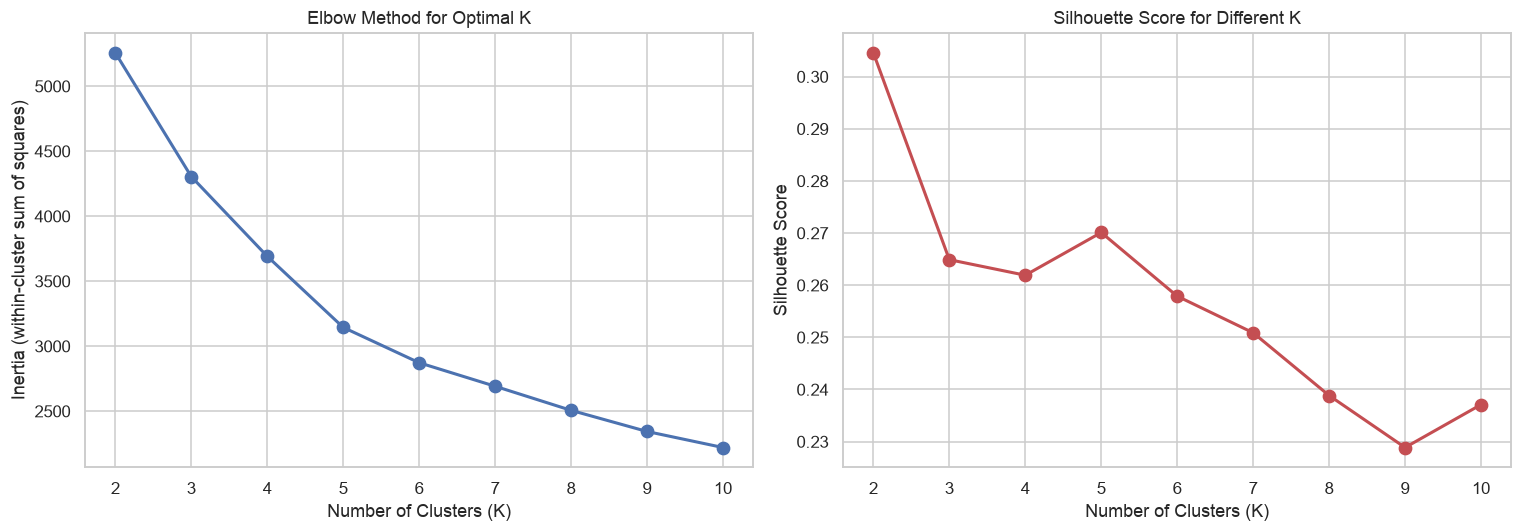

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Calculate inertia for different K values
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot elbow curve
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia (within-cluster sum of squares)')
ax[0].set_title('Elbow Method for Optimal K')
ax[0].grid(True)

# Calculate silhouette scores
silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)

# Silhouette plot
ax[1].plot(range(2, 11), silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('Silhouette Score for Different K')
ax[1].grid(True)

plt.tight_layout()

# Optimal K
optimal_k_elbow = K_range[np.argmin(np.diff(inertias, 2))] + 1
optimal_k_silhouette = range(2, 11)[np.argmax(silhouette_scores)]

print(f"Optimal K (elbow): {optimal_k_elbow}")
print(f"Optimal K (silhouette): {optimal_k_silhouette}")
print("Silhouette scores:")
for k, s in zip(range(2, 11), silhouette_scores):
    print(f"  K={k}: {s:.3f}")

## Final clustering

Let's use K=3 or K=4 and interpret the clusters.

In [5]:
# Cluster with K=3
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

# Add cluster labels to dataframe
daily_summary['cluster'] = labels

print("Cluster distribution:")
print(daily_summary['cluster'].value_counts().sort_index())

# Cluster centers
print("\nCluster centers (scaled):")
centers = pd.DataFrame(km.cluster_centers_, columns=feature_cols)
print(centers)

# Inverse transform to original scale
centers_original = scaler.inverse_transform(centers.values)
centers_df = pd.DataFrame(centers_original, columns=feature_cols)
print("\nCluster centers (original scale):")
print(centers_df)

# Cluster characteristics
print("\nCluster characteristics:")
for cluster in range(k):
    cluster_data = daily_summary[daily_summary['cluster'] == cluster]
    print(f"\nCluster {cluster}:")
    print(f"  Size: {len(cluster_data)} days ({100*len(cluster_data)/len(daily_summary):.1f}%)")
    print(f"  Avg temp: {cluster_data['temp_mean'].mean():.2f} C")
    print(f"  Temp range: {cluster_data['temp_min'].min():.2f} - {cluster_data['temp_max'].max():.2f} C")
    print(f"  Avg current: {np.sqrt((cluster_data['u_current']**2 + cluster_data['v_current']**2).mean()):.3f} m/s")

Cluster distribution:
cluster
0    328
1    242
2    282
Name: count, dtype: int64

Cluster centers (scaled):
   temp_mean  temp_std  temp_min  temp_max  salinity_mean  salinity_std  \
0  -0.410455 -0.767542  0.369469 -0.771311       0.275544     -0.661829   
1  -0.086223 -0.358295  0.133383 -0.278953      -0.817640      0.805163   
2   0.551402  1.200217 -0.544201  1.136512       0.381172      0.078832   

   u_current  v_current  dc_dz_mean  
0  -0.142231   0.297676    0.671889  
1   0.911810  -1.141465    0.443725  
2  -0.617044   0.633322   -1.162273  

Cluster centers (original scale):
   temp_mean  temp_std   temp_min   temp_max  salinity_mean  salinity_std  \
0  12.508535  0.501616  11.248360  12.896635      33.289137      0.110120   
1  12.792862  0.782561  11.013458  13.573628      33.099899      0.311834   
2  13.352009  1.852471  10.339270  15.519893      33.307422      0.211962   

   u_current  v_current  dc_dz_mean  
0  -0.011796   0.021103   -0.046597  
1   0.020615  -0.

## Visualizing clusters

Let's see how the clusters look in 2D space.

PCA explained variance:
  PC1: 39.42%
  PC2: 23.90%


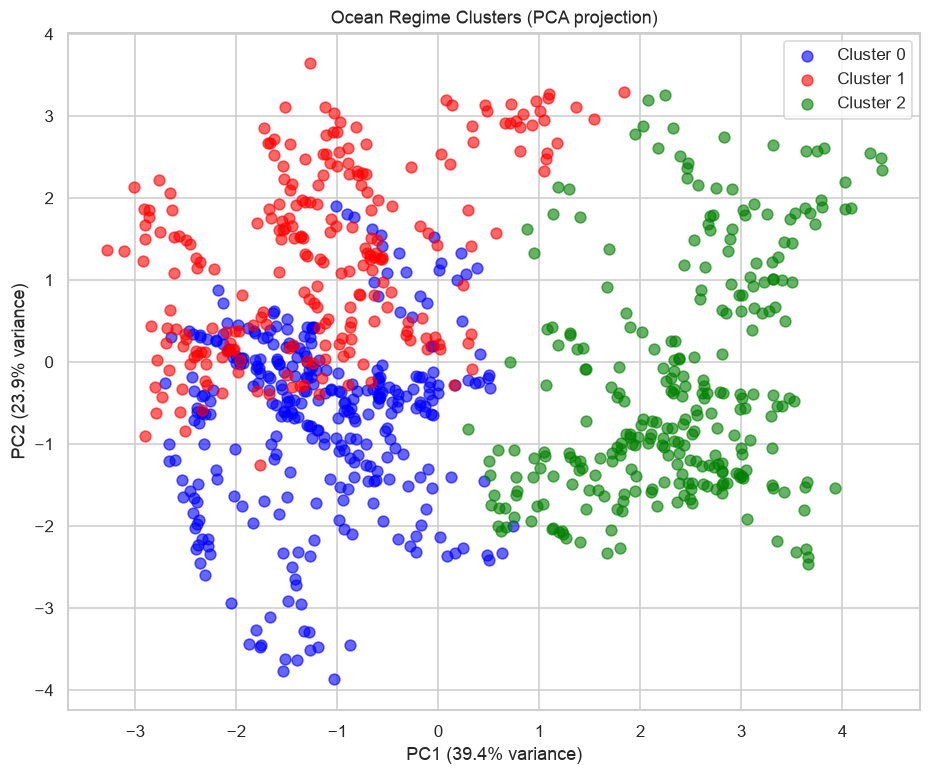

In [6]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA explained variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['blue', 'red', 'green']
for cluster in range(k):
    idx = labels == cluster
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], c=colors[cluster], 
               label=f'Cluster {cluster}', alpha=0.6, s=50)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Ocean Regime Clusters (PCA projection)')
ax.legend()
ax.grid(True)